# Experiment A — Method comparison by network period

This notebook compares the Experiment A Human Pose Estimation methods using the raw prediction CSV files produced by each experiment folder.

It computes dataset-weighted:

- MPJPE in pixels
- PCK@0.2
- PCK@0.4

The aggregation keeps the network period/detection rate explicit. Flow-period variants are kept separate for the MoveEnetFlow outputs, so rows from different `fp_*` folders are not mixed. Methods that do not have a flow-period folder are compared directly as their own method variant.

The eH36M sequences listed as corrupted are skipped before loading ground truth.


In [10]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from datasets.utils import constants as ds_constants, parsing as ds_parsing

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Configuration

Edit `MAX_FILES_PER_CONFIG` if you want a quick dry-run on a small subset. Leave it as `None` for the full comparison.


In [ ]:
ROOT_DIR = Path('/workspace/moveEnetFlow')
EXP_A_DIR = ROOT_DIR / 'experiments' / 'ExpA'
COMPARISON_DIR = EXP_A_DIR / 'Comparison'
RESULTS_DIR = COMPARISON_DIR / 'results'
PLOTS_DIR = COMPARISON_DIR / 'plots'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GT_ROOTS = {
    'dhp19': Path('/data/dhp19_testing_set_S13toS17'),
    'eh36m': Path('/data/eh36m_testing_set_S9S11/events'),
}

EXPERIMENTS = [
    {
        'family': 'MoveEnetFlow',
        'dataset': 'dhp19',
        'raw_dir': EXP_A_DIR / 'expA_accuracy_vs_network_period' / 'dhp19_full_test' / 'results' / 'raw',
        'pattern': 'fp_*/np_*/*.csv',
    },
    {
        'family': 'MoveEnetFlow',
        'dataset': 'eh36m',
        'raw_dir': EXP_A_DIR / 'expA_accuracy_vs_network_period' / 'eh36m_full_test' / 'results' / 'raw',
        'pattern': 'fp_*/np_*/*.csv',
    },
    {
        'family': 'EventPointPose',
        'dataset': 'dhp19',
        'raw_dir': EXP_A_DIR / 'EPP_expA_accuracy_vs_network_period' / 'dhp19_full_test' / 'results' / 'raw',
        'pattern': 'np_*/*.csv',
    },
    {
        'family': 'OpenPose',
        'dataset': 'eh36m',
        'raw_dir': EXP_A_DIR / 'OP_expA_accuracy_vs_network_period' / 'h36m_full_test_old' / 'results' / 'raw',
        'pattern': 'np_*/*.csv',
    },
    {
        'family': 'YOLOPose',
        'dataset': 'eh36m',
        'raw_dir': EXP_A_DIR / 'YOLO_expA_accuracy_vs_network_period' / 'h36m_full_test' / 'results' / 'raw',
        'pattern': 'np_*/*.csv',
    },
]

PCK_THRESHOLDS = [0.2, 0.4]
REF_JOINT_1 = 1
REF_JOINT_2 = 5
MAX_FILES_PER_CONFIG = None

# User-provided corrupted eH36M GT files. The whole sequence is skipped for every method.
CORRUPTED_EH36M_GT_FILES = [
    'cam4_S11_Greeting/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Eating/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Greeting/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Photo/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Photo_1/ch0GT50Hzskeleton/data.log',
    'cam4_S9_SittingDown_1/ch0GT50Hzskeleton/data.log',
    'cam4_S9_Waiting_1/ch0GT50Hzskeleton/data.log',
    'Cam4_S9_Walking/ch0GT50Hzskeleton/data.log',
]
CORRUPTED_EH36M_SEQUENCES = {
    Path(p).parts[0].lower()
    for p in CORRUPTED_EH36M_GT_FILES
}

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 HPECore joints, got {len(joint_names)}'

print('Comparison output:', COMPARISON_DIR)
print('PCK thresholds:', PCK_THRESHOLDS)
print(f'PCK reference distance: joint {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) to joint {REF_JOINT_2} ({joint_names[REF_JOINT_2]})')
print('Skipped eH36M sequences:', sorted(CORRUPTED_EH36M_SEQUENCES))


Comparison output: /workspace/moveEnetFlow/experiments/ExpA/Comparison
PCK thresholds: [0.2, 0.4]
PCK reference distance: joint 1 (shoulder_right) to joint 5 (hip_left)
Skipped eH36M sequences: ['cam4_s11_greeting', 'cam4_s9_eating', 'cam4_s9_greeting', 'cam4_s9_photo', 'cam4_s9_photo_1', 'cam4_s9_sittingdown_1', 'cam4_s9_waiting_1', 'cam4_s9_walking']


## Utility functions


In [12]:
PERIOD_PATTERN = r'(?:\d+p\d+|\d+)'


def normalize_csv_name(csv_path: Path) -> str:
    """Normalize accidental spaces around eH36M file names, without changing the file on disk."""
    name = csv_path.name.strip()
    return re.sub(r'\s+\.csv$', '.csv', name)


def tag_to_period(tag: str) -> float:
    return float(str(tag).strip().replace('p', '.'))


def period_from_parent(csv_path: Path, prefix: str):
    """Find a period folder such as np_0p1 or fp_0p005 in the path parents."""
    for parent in csv_path.parents:
        name = parent.name.strip()
        if name.startswith(prefix):
            tag = name[len(prefix):].strip()
            return tag, tag_to_period(tag)
    return None, np.nan


def sequence_base(seq_key: str) -> str:
    return seq_key.split('__')[0]


def is_corrupted_eh36m_sequence(seq_key: str) -> bool:
    return sequence_base(seq_key).lower() in CORRUPTED_EH36M_SEQUENCES


def method_variant_label(method: str, flow_period_s) -> str:
    # MoveEnet only does not use optical flow, so FP does not define a separate variant.
    if method == 'MoveEnet only' or pd.isna(flow_period_s):
        return method
    return f'{method} (fp={float(flow_period_s):g}s)'


def extract_metadata_from_name(csv_path: Path, family: str, dataset: str) -> dict:
    name = normalize_csv_name(csv_path)

    moveenet = re.fullmatch(
        rf'(?P<sequence>.+?)__(?P<channel>ch\d+dvs)_'
        rf'(?P<method>moveenet_ofk|moveenet_only|moveenet)_'
        rf'np_(?P<np>{PERIOD_PATTERN})_fp_(?P<fp>{PERIOD_PATTERN})\.csv',
        name,
    )
    if moveenet:
        method_key = moveenet.group('method')
        method = 'MoveEnet + OFK' if method_key == 'moveenet_ofk' else 'MoveEnet only'
        raw_flow_period_s = tag_to_period(moveenet.group('fp'))
        flow_period_s = np.nan if method_key == 'moveenet_only' else raw_flow_period_s
        seq_key = f"{moveenet.group('sequence')}__{moveenet.group('channel')}"
        return {
            'sequence': seq_key,
            'method': method,
            'network_period_s': tag_to_period(moveenet.group('np')),
            'flow_period_s': flow_period_s,
            'raw_flow_period_s': raw_flow_period_s,
        }

    epp = re.fullmatch(
        rf'(?P<sequence>.+?)__(?P<channel>ch\d+dvs)_net_flow_'
        rf'np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if epp:
        seq_key = f"{epp.group('sequence')}__{epp.group('channel')}"
        return {
            'sequence': seq_key,
            'method': 'EventPointPose',
            'network_period_s': tag_to_period(epp.group('np')),
            'flow_period_s': np.nan,
        }

    openpose = re.fullmatch(
        rf'(?P<sequence>.+?)_openpose_np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if openpose:
        return {
            'sequence': openpose.group('sequence'),
            'method': 'OpenPose',
            'network_period_s': tag_to_period(openpose.group('np')),
            'flow_period_s': np.nan,
        }

    yolopose = re.fullmatch(
        rf'(?P<sequence>.+?)_yolopose_np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if yolopose:
        return {
            'sequence': yolopose.group('sequence'),
            'method': 'YOLOPose',
            'network_period_s': tag_to_period(yolopose.group('np')),
            'flow_period_s': np.nan,
        }

    raise ValueError(f'Unrecognized {family}/{dataset} filename: {csv_path.name}')


def extract_metadata(csv_path: Path, family: str, dataset: str) -> dict:
    meta = extract_metadata_from_name(csv_path, family=family, dataset=dataset)

    np_tag, network_period_from_folder = period_from_parent(csv_path, 'np_')
    if np_tag is None:
        raise ValueError(f'Missing np_* folder for {csv_path}')
    if not np.isclose(meta['network_period_s'], network_period_from_folder):
        raise ValueError(
            f"Network period mismatch for {csv_path.name}: "
            f"filename={meta['network_period_s']} folder={network_period_from_folder}"
        )

    fp_tag, flow_period_from_folder = period_from_parent(csv_path, 'fp_')
    expected_flow_period_s = meta.get('raw_flow_period_s', meta['flow_period_s'])
    if not pd.isna(expected_flow_period_s):
        if fp_tag is None:
            raise ValueError(f'Missing fp_* folder for {csv_path}')
        if not np.isclose(expected_flow_period_s, flow_period_from_folder):
            raise ValueError(
                f"Flow period mismatch for {csv_path.name}: "
                f"filename={expected_flow_period_s} folder={flow_period_from_folder}"
            )

    meta['dataset'] = dataset
    meta['family'] = family
    meta['csv_path'] = csv_path
    meta['detection_rate_hz'] = 1.0 / meta['network_period_s']
    meta['method_variant'] = method_variant_label(meta['method'], meta['flow_period_s'])
    return meta



def is_empty_prediction_csv(csv_path: Path) -> bool:
    """Return True for missing-content prediction files, including header-only CSVs."""
    if csv_path.stat().st_size == 0:
        return True
    with csv_path.open('r', encoding='utf-8', errors='ignore') as f:
        data_lines = [line for line in f if line.strip()]
    return len(data_lines) <= 1


def load_pred_eval_csv(csv_path: Path):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.size == 0:
        raise ValueError(f'Empty prediction CSV: {csv_path}')
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0].astype(float)
    joints = arr[:, 2:28].reshape(-1, 13, 2).astype(float)
    return ts, joints


def gt_path_from_seq_key(seq_key: str, dataset: str) -> Path:
    base = sequence_base(seq_key)

    if dataset == 'dhp19':
        channel_match = re.search(r'__(ch\d+)dvs$', seq_key)
        if channel_match is None:
            raise ValueError(f'DHP19 sequence is missing a DVS channel: {seq_key}')
        gt_folder = f'{channel_match.group(1)}GT200Hzskeleton'
        return GT_ROOTS['dhp19'] / base / gt_folder / 'data.log'

    if dataset == 'eh36m':
        return GT_ROOTS['eh36m'] / base / 'ch0GT200Hzskeleton' / 'data.log'

    raise ValueError(f'Unknown dataset: {dataset}')


def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray) -> np.ndarray:
    ts_gt_raw = np.asarray(gt_data['ts'], dtype=float)
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))

    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = np.asarray(gt_data[joint][:, 0], dtype=float)
        y_raw = np.asarray(gt_data[joint][:, 1], dtype=float)
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)
    return joints_gt


def calculate_pck_binary(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)
    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)
    ref_dist = np.maximum(ref_dist, 1e-6)
    return (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)


## Discover prediction CSV files


In [13]:
records = []
parse_errors = []

# Empty prediction CSVs are discarded before metric computation.
# They usually contain no prediction rows and would otherwise bias or break aggregation.
empty_csv_files = []

for cfg in EXPERIMENTS:
    raw_dir = cfg['raw_dir']
    if not raw_dir.exists():
        warnings.warn(f"Raw directory does not exist and will be skipped: {raw_dir}")
        continue

    files = sorted(raw_dir.glob(cfg['pattern']))
    if MAX_FILES_PER_CONFIG is not None:
        files = files[:MAX_FILES_PER_CONFIG]

    for csv_path in files:
        try:
            rec = extract_metadata(csv_path, family=cfg['family'], dataset=cfg['dataset'])
            rec['skip_reason'] = ''
            if rec['dataset'] == 'eh36m' and is_corrupted_eh36m_sequence(rec['sequence']):
                rec['skip_reason'] = 'corrupted eh36m GT sequence'
            elif is_empty_prediction_csv(csv_path):
                rec['skip_reason'] = 'empty prediction CSV'
                empty_csv_files.append(str(csv_path))
            records.append(rec)
        except Exception as exc:
            parse_errors.append({
                'family': cfg['family'],
                'dataset': cfg['dataset'],
                'csv_path': str(csv_path),
                'error': repr(exc),
            })

if parse_errors:
    print(f'Parse errors: {len(parse_errors)}')
    display(pd.DataFrame(parse_errors).head(20))

if not records:
    raise RuntimeError('No prediction CSV files were discovered.')

df_files_all = pd.DataFrame(records)
df_files = df_files_all[df_files_all['skip_reason'].eq('')].copy()
df_skipped = df_files_all[df_files_all['skip_reason'].ne('')].copy()

# MoveEnet only predictions do not use optical flow. The fp_0p005 and fp_0p01
# files are duplicate variants, so keep one CSV per dataset/sequence/network period
# before metric computation to avoid plotting duplicate curves or double-counting samples.
df_moveenet_only_duplicates = pd.DataFrame()
df_files = df_files.sort_values(['dataset', 'sequence', 'network_period_s', 'csv_path']).reset_index(drop=True)
moveenet_only_mask = df_files['method'].eq('MoveEnet only')
if moveenet_only_mask.any():
    dedup_cols = ['dataset', 'family', 'sequence', 'method', 'network_period_s']
    duplicate_mask = moveenet_only_mask & df_files.duplicated(subset=dedup_cols, keep='first')
    df_moveenet_only_duplicates = df_files[duplicate_mask].copy()
    df_files = df_files[~duplicate_mask].copy().reset_index(drop=True)

empty_csv_files = sorted(empty_csv_files)
df_empty_csv_files = pd.DataFrame({'csv_path': empty_csv_files})
if len(df_empty_csv_files):
    df_empty_csv_files['file_name'] = df_empty_csv_files['csv_path'].map(lambda p: Path(p).name)
else:
    df_empty_csv_files['file_name'] = pd.Series(dtype=str)

print(f'Discovered CSVs: {len(df_files_all)}')
print(f"Skipped corrupted eH36M CSVs: {df_skipped['skip_reason'].eq('corrupted eh36m GT sequence').sum()}")
print(f'Discarded empty CSVs: {len(empty_csv_files)}')
print(f'Discarded duplicate MoveEnet-only FP CSVs: {len(df_moveenet_only_duplicates)}')
print(f'CSV files to evaluate: {len(df_files)}')

summary_cols = ['dataset', 'family', 'method', 'method_variant', 'flow_period_s', 'network_period_s', 'detection_rate_hz']
discovery_summary = (
    df_files
    .groupby(summary_cols, dropna=False)
    .size()
    .reset_index(name='n_csv')
    .sort_values(['dataset', 'family', 'network_period_s', 'method_variant'])
)
display(discovery_summary)

if len(df_empty_csv_files):
    print('Empty prediction CSV files discarded from metric analysis:')
    display(df_empty_csv_files)

if len(df_moveenet_only_duplicates):
    print('Duplicate MoveEnet-only FP CSVs discarded from metric analysis:')
    display(
        df_moveenet_only_duplicates[
            ['dataset', 'sequence', 'network_period_s', 'csv_path']
        ].head(20)
    )

if len(df_skipped):
    skipped_summary = (
        df_skipped
        .groupby(['dataset', 'sequence', 'skip_reason'])
        .size()
        .reset_index(name='n_csv')
        .sort_values(['dataset', 'sequence'])
    )
    display(skipped_summary)


Discovered CSVs: 7309
Skipped corrupted eH36M CSVs: 328
Discarded empty CSVs: 87
Discarded duplicate MoveEnet-only FP CSVs: 1920
CSV files to evaluate: 4974


,dataset,family,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,n_csv
0,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,80
5,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.01s),0.010,0.02,50.0,80
10,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.02s),0.020,0.02,50.0,80
15,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.02,50.0,80
1,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.05,20.0,80
6,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.01s),0.010,0.05,20.0,80
11,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.02s),0.020,0.05,20.0,80
16,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.05,20.0,80
2,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.10,10.0,80
7,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.01s),0.010,0.10,10.0,80


Empty prediction CSV files discarded from metric analysis:


,csv_path,file_name
0,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam2_S11_SittingDown_yolopose_np_0p02.csv
1,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam2_S9_Photo_1_yolopose_np_0p02.csv
2,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam2_S9_Purchases_1_yolopose_np_0p02.csv
3,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S11_Eating_yolopose_np_0p02.csv
4,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S11_Purchases_1_yolopose_np_0p02.csv
...,...,...
82,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Greeting_1_yolopose_np_0p5.csv
83,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Posing_yolopose_np_0p5.csv
84,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Purchases_yolopose_np_0p5.csv
85,/workspace/moveEnetFlow/experiments/ExpA/YOLO_...,cam4_S9_Smoking_1_yolopose_np_0p5.csv


Duplicate MoveEnet-only FP CSVs discarded from metric analysis:


,dataset,sequence,network_period_s,csv_path
3,dhp19,S13_1_1__ch2dvs,0.02,/workspace/moveEnetFlow/experiments/ExpA/expA_...
5,dhp19,S13_1_1__ch2dvs,0.02,/workspace/moveEnetFlow/experiments/ExpA/expA_...
9,dhp19,S13_1_1__ch2dvs,0.05,/workspace/moveEnetFlow/experiments/ExpA/expA_...
11,dhp19,S13_1_1__ch2dvs,0.05,/workspace/moveEnetFlow/experiments/ExpA/expA_...
15,dhp19,S13_1_1__ch2dvs,0.10,/workspace/moveEnetFlow/experiments/ExpA/expA_...
17,dhp19,S13_1_1__ch2dvs,0.10,/workspace/moveEnetFlow/experiments/ExpA/expA_...
21,dhp19,S13_1_1__ch2dvs,0.20,/workspace/moveEnetFlow/experiments/ExpA/expA_...
23,dhp19,S13_1_1__ch2dvs,0.20,/workspace/moveEnetFlow/experiments/ExpA/expA_...
27,dhp19,S13_1_1__ch2dvs,0.50,/workspace/moveEnetFlow/experiments/ExpA/expA_...
29,dhp19,S13_1_1__ch2dvs,0.50,/workspace/moveEnetFlow/experiments/ExpA/expA_...


,dataset,sequence,skip_reason,n_csv
0,eh36m,cam2_S11_Discussion_1,empty prediction CSV,1
1,eh36m,cam2_S11_Eating,empty prediction CSV,1
2,eh36m,cam2_S11_Eating_1,empty prediction CSV,1
3,eh36m,cam2_S11_Greeting,empty prediction CSV,1
4,eh36m,cam2_S11_Greeting_2,empty prediction CSV,1
...,...,...,...,...
77,eh36m,cam4_S9_Waiting_1__ch0dvs,corrupted eh36m GT sequence,30
78,eh36m,cam4_S9_WalkDog_1,empty prediction CSV,1
79,eh36m,cam4_S9_WalkTogether,empty prediction CSV,3
80,eh36m,cam4_S9_Walking,corrupted eh36m GT sequence,11


## Compute MPJPE and PCK per sequence

This cell reads every prediction file, interpolates the GT skeleton to the prediction timestamps, and computes per-sequence metrics. Dataset-level aggregation happens in the next cell.


In [14]:
gt_cache = {}
rows = []
missing_gt = []
eval_errors = []

print('Processing prediction CSV files...')

for idx, rec in enumerate(df_files.to_dict('records'), start=1):
    if idx == 1 or idx % 100 == 0 or idx == len(df_files):
        print(f'  [{idx}/{len(df_files)}]')

    csv_path = rec['csv_path']
    gt_path = gt_path_from_seq_key(rec['sequence'], rec['dataset'])

    if not gt_path.exists():
        missing_gt.append({**rec, 'gt_path': gt_path})
        continue

    try:
        if gt_path not in gt_cache:
            gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
                gt_path,
                multi_channel=False,
            )

        ts_pred, joints_pred = load_pred_eval_csv(csv_path)
        joints_gt = interp_gt_to_pred_ts(gt_cache[gt_path], ts_pred)

        valid_rows = (
            np.isfinite(ts_pred)
            & np.isfinite(joints_pred).all(axis=(1, 2))
            & np.isfinite(joints_gt).all(axis=(1, 2))
        )
        if not valid_rows.any():
            raise ValueError('No finite prediction/GT rows after filtering')

        ts_pred = ts_pred[valid_rows]
        joints_pred = joints_pred[valid_rows]
        joints_gt = joints_gt[valid_rows]

        err = np.linalg.norm(joints_pred - joints_gt, axis=2)
        n_samples = int(err.shape[0])
        n_points = int(err.size)

        row = {
            'dataset': rec['dataset'],
            'family': rec['family'],
            'sequence': rec['sequence'],
            'method': rec['method'],
            'method_variant': rec['method_variant'],
            'flow_period_s': rec['flow_period_s'],
            'network_period_s': rec['network_period_s'],
            'detection_rate_hz': rec['detection_rate_hz'],
            'csv_path': str(csv_path),
            'gt_path': str(gt_path),
            'n_samples': n_samples,
            'n_points': n_points,
            'sum_err_px': float(err.sum()),
            'mpjpe_px': float(err.mean()),
        }

        for th in PCK_THRESHOLDS:
            pck_binary = calculate_pck_binary(joints_pred, joints_gt, th)
            row[f'pck_{th:.1f}'] = float(pck_binary.mean() * 100.0)
            row[f'pck_{th:.1f}_correct_points'] = float(pck_binary.sum())

        rows.append(row)
    except Exception as exc:
        eval_errors.append({**rec, 'gt_path': gt_path, 'error': repr(exc)})

if missing_gt:
    print(f'Missing GT files: {len(missing_gt)}')
    display(pd.DataFrame(missing_gt)[['dataset', 'family', 'sequence', 'method', 'gt_path']].head(20))

if eval_errors:
    print(f'Evaluation errors: {len(eval_errors)}')
    display(pd.DataFrame(eval_errors)[['dataset', 'family', 'sequence', 'method', 'csv_path', 'error']].head(20))

if not rows:
    raise RuntimeError('No rows were evaluated. Check GT roots, raw CSV paths, and parse errors above.')

df_seq = (
    pd.DataFrame(rows)
    .sort_values(['dataset', 'network_period_s', 'method_variant', 'sequence'])
    .reset_index(drop=True)
)

print(f'Evaluated sequence rows: {len(df_seq)}')
display(df_seq.head())


Processing prediction CSV files...
  [1/4974]
  [100/4974]
  [200/4974]
  [300/4974]
  [400/4974]
  [500/4974]
  [600/4974]
  [700/4974]
  [800/4974]
  [900/4974]
  [1000/4974]
  [1100/4974]
  [1200/4974]
  [1300/4974]
  [1400/4974]
  [1500/4974]
  [1600/4974]
  [1700/4974]
  [1800/4974]
  [1900/4974]
  [2000/4974]
  [2100/4974]
  [2200/4974]
  [2300/4974]
  [2400/4974]
  [2500/4974]
  [2600/4974]
  [2700/4974]
  [2800/4974]
  [2900/4974]
  [3000/4974]
  [3100/4974]
  [3200/4974]
  [3300/4974]
  [3400/4974]
  [3500/4974]
  [3600/4974]
  [3700/4974]
  [3800/4974]
  [3900/4974]
  [4000/4974]
  [4100/4974]
  [4200/4974]
  [4300/4974]
  [4400/4974]
  [4500/4974]
  [4600/4974]
  [4700/4974]
  [4800/4974]
  [4900/4974]
  [4974/4974]
Missing GT files: 20


,dataset,family,sequence,method,gt_path
0,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
1,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
2,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
3,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
4,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
5,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
6,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
7,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
8,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...
9,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT...


Evaluated sequence rows: 4954


,dataset,family,sequence,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,csv_path,gt_path,n_samples,n_points,sum_err_px,mpjpe_px,pck_0.2,pck_0.2_correct_points,pck_0.4,pck_0.4_correct_points
0,dhp19,MoveEnetFlow,S13_1_1__ch2dvs,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,/workspace/moveEnetFlow/experiments/ExpA/expA_...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch2GT...,4230,54990,357113.444553,6.494152,83.406073,45865.0,99.663574,54805.0
1,dhp19,MoveEnetFlow,S13_1_1__ch3dvs,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,/workspace/moveEnetFlow/experiments/ExpA/expA_...,/data/dhp19_testing_set_S13toS17/S13_1_1/ch3GT...,4127,53651,306854.421037,5.719454,93.778306,50313.0,99.878848,53586.0
2,dhp19,MoveEnetFlow,S13_1_2__ch2dvs,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,/workspace/moveEnetFlow/experiments/ExpA/expA_...,/data/dhp19_testing_set_S13toS17/S13_1_2/ch2GT...,4050,52650,305234.945021,5.797435,93.306744,49126.0,98.516619,51869.0
3,dhp19,MoveEnetFlow,S13_1_2__ch3dvs,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,/workspace/moveEnetFlow/experiments/ExpA/expA_...,/data/dhp19_testing_set_S13toS17/S13_1_2/ch3GT...,3873,50349,283084.123960,5.622438,96.442831,48558.0,99.330670,50012.0
4,dhp19,MoveEnetFlow,S13_1_3__ch2dvs,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,/workspace/moveEnetFlow/experiments/ExpA/expA_...,/data/dhp19_testing_set_S13toS17/S13_1_3/ch2GT...,3458,44954,198631.805574,4.418557,94.772434,42604.0,98.772079,44402.0


## Dataset-weighted aggregation

MPJPE is aggregated by summing all joint errors and dividing by the number of evaluated joint points. PCK is aggregated by summing correct joint points, so longer sequences contribute proportionally.


In [15]:
pck_cols = [f'pck_{th:.1f}' for th in PCK_THRESHOLDS]
group_cols = [
    'dataset',
    'family',
    'method',
    'method_variant',
    'flow_period_s',
    'network_period_s',
    'detection_rate_hz',
]

agg_spec = {
    'sum_err_px': ('sum_err_px', 'sum'),
    'n_points': ('n_points', 'sum'),
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}
for col in pck_cols:
    agg_spec[f'{col}_correct_points'] = (f'{col}_correct_points', 'sum')

df_table = (
    df_seq
    .groupby(group_cols, dropna=False, as_index=False)
    .agg(**agg_spec)
)

df_table['mpjpe_px'] = df_table['sum_err_px'] / df_table['n_points']
for col in pck_cols:
    df_table[col] = df_table[f'{col}_correct_points'] / df_table['n_points'] * 100.0

drop_cols = [f'{col}_correct_points' for col in pck_cols]
df_table = df_table.drop(columns=drop_cols)

df_table = (
    df_table
    .sort_values(['dataset', 'network_period_s', 'method_variant'])
    .reset_index(drop=True)
)

compact_cols = [
    'dataset',
    'network_period_s',
    'detection_rate_hz',
    'method_variant',
    'n_sequences',
    'n_samples',
    'n_points',
    'mpjpe_px',
] + pck_cols

print('Dataset-weighted comparison table:')
display(df_table[compact_cols])


Dataset-weighted comparison table:


,dataset,network_period_s,detection_rate_hz,method_variant,n_sequences,n_samples,n_points,mpjpe_px,pck_0.2,pck_0.4
0,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,6.630619,89.085936,98.396350
1,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.01s),79,277751,3610763,6.618128,89.125927,98.387238
2,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.02s),79,277751,3610763,6.627149,89.034257,98.358740
3,dhp19,0.02,50.0,MoveEnet only,79,277751,3610763,6.644225,88.899271,98.399258
4,dhp19,0.05,20.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,6.790448,88.089304,98.292826
5,dhp19,0.05,20.0,MoveEnet + OFK (fp=0.01s),79,277751,3610763,6.763464,88.289954,98.287315
6,dhp19,0.05,20.0,MoveEnet + OFK (fp=0.02s),79,277751,3610763,6.764466,88.326456,98.205449
7,dhp19,0.05,20.0,MoveEnet only,79,277751,3610763,6.711935,88.541065,98.310274
8,dhp19,0.10,10.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,7.028076,86.559627,98.033878
9,dhp19,0.10,10.0,MoveEnet + OFK (fp=0.01s),79,277751,3610763,6.988226,86.860063,98.073205


## Save comparison CSV files


In [16]:
per_sequence_path = RESULTS_DIR / 'comparison_per_sequence_metrics.csv'
comparison_path = RESULTS_DIR / 'comparison_dataset_weighted_metrics.csv'
df_seq.to_csv(per_sequence_path, index=False)
df_table.to_csv(comparison_path, index=False)
print('Saved:', per_sequence_path)
print('Saved:', comparison_path)


empty_csv_list_path = RESULTS_DIR / 'discarded_empty_csv_files.txt'
empty_csv_table_path = RESULTS_DIR / 'discarded_empty_csv_files.csv'
empty_csv_list_path.write_text('\n'.join(empty_csv_files) + ('\n' if empty_csv_files else ''), encoding='utf-8')
df_empty_csv_files.to_csv(empty_csv_table_path, index=False)
print('Saved:', empty_csv_list_path)
print('Saved:', empty_csv_table_path)

for metric in ['mpjpe_px'] + pck_cols:
    pivot = (
        df_table
        .pivot_table(
            index=['dataset', 'network_period_s', 'detection_rate_hz'],
            columns='method_variant',
            values=metric,
            aggfunc='first',
        )
        .reset_index()
    )
    pivot.columns.name = None
    out_name = 'comparison_mpjpe_wide.csv' if metric == 'mpjpe_px' else f'comparison_{metric}_wide.csv'
    out_path = RESULTS_DIR / out_name
    pivot.to_csv(out_path, index=False)
    print('Saved:', out_path)
    display(pivot)


Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/comparison_per_sequence_metrics.csv
Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/comparison_dataset_weighted_metrics.csv
Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/discarded_empty_csv_files.txt
Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/discarded_empty_csv_files.csv
Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/comparison_mpjpe_wide.csv


,dataset,network_period_s,detection_rate_hz,MoveEnet + OFK (fp=0.005s),MoveEnet + OFK (fp=0.01s),MoveEnet + OFK (fp=0.02s),MoveEnet only,OpenPose,YOLOPose
0,dhp19,0.02,50.0,6.630619,6.618128,6.627149,6.644225,NaN,NaN
1,dhp19,0.05,20.0,6.790448,6.763464,6.764466,6.711935,NaN,NaN
2,dhp19,0.10,10.0,7.028076,6.988226,6.980548,6.881212,NaN,NaN
3,dhp19,0.20,5.0,7.466665,7.410892,7.383583,7.304019,NaN,NaN
4,dhp19,0.50,2.0,8.678712,8.564153,8.467008,8.628659,NaN,NaN
5,eh36m,0.01,100.0,NaN,NaN,NaN,NaN,14.821805,NaN
6,eh36m,0.02,50.0,15.503393,15.536635,15.604788,15.853061,14.821805,10.509684
7,eh36m,0.05,20.0,15.829966,15.873646,15.968719,16.015718,15.004053,10.519898
8,eh36m,0.10,10.0,16.388949,16.443474,16.540623,16.500953,15.471760,11.095828
9,eh36m,0.20,5.0,17.540156,17.615476,17.747082,17.899857,16.879350,12.553709


Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/comparison_pck_0.2_wide.csv


,dataset,network_period_s,detection_rate_hz,MoveEnet + OFK (fp=0.005s),MoveEnet + OFK (fp=0.01s),MoveEnet + OFK (fp=0.02s),MoveEnet only,OpenPose,YOLOPose
0,dhp19,0.02,50.0,89.085936,89.125927,89.034257,88.899271,NaN,NaN
1,dhp19,0.05,20.0,88.089304,88.289954,88.326456,88.541065,NaN,NaN
2,dhp19,0.10,10.0,86.559627,86.860063,87.021663,87.528259,NaN,NaN
3,dhp19,0.20,5.0,83.984936,84.294511,84.664654,85.642314,NaN,NaN
4,dhp19,0.50,2.0,78.804618,79.033102,79.751565,81.856494,NaN,NaN
5,eh36m,0.01,100.0,NaN,NaN,NaN,NaN,92.647723,NaN
6,eh36m,0.02,50.0,79.455139,79.361737,79.271392,78.980584,92.647723,90.369081
7,eh36m,0.05,20.0,78.765969,78.653868,78.449717,78.727404,92.530481,90.447516
8,eh36m,0.10,10.0,77.575817,77.449089,77.188549,77.805950,91.556826,89.247065
9,eh36m,0.20,5.0,75.184903,75.044823,74.678996,74.686448,87.470967,85.324911


Saved: /workspace/moveEnetFlow/experiments/ExpA/Comparison/results/comparison_pck_0.4_wide.csv


,dataset,network_period_s,detection_rate_hz,MoveEnet + OFK (fp=0.005s),MoveEnet + OFK (fp=0.01s),MoveEnet + OFK (fp=0.02s),MoveEnet only,OpenPose,YOLOPose
0,dhp19,0.02,50.0,98.396350,98.387238,98.358740,98.399258,NaN,NaN
1,dhp19,0.05,20.0,98.292826,98.287315,98.205449,98.310274,NaN,NaN
2,dhp19,0.10,10.0,98.033878,98.073205,97.938469,98.024960,NaN,NaN
3,dhp19,0.20,5.0,97.261244,97.355324,97.310319,96.949841,NaN,NaN
4,dhp19,0.50,2.0,94.327487,94.613798,94.995434,93.806794,NaN,NaN
5,eh36m,0.01,100.0,NaN,NaN,NaN,NaN,97.223055,NaN
6,eh36m,0.02,50.0,92.476758,92.447765,92.439368,92.127963,97.223055,97.228597
7,eh36m,0.05,20.0,92.260907,92.221542,92.153246,92.011360,97.177776,97.341407
8,eh36m,0.10,10.0,91.823119,91.763174,91.682832,91.722672,97.056447,97.031246
9,eh36m,0.20,5.0,90.776251,90.692559,90.561805,90.593234,96.161337,96.084660


## Plot helpers


In [17]:
DATASET_LABELS = {
    'dhp19': 'DHP19',
    'eh36m': 'eH36M',
}

METHOD_ORDER = [
    'MoveEnet only',
    'MoveEnet + OFK (fp=0.005s)',
    'MoveEnet + OFK (fp=0.01s)',
    'EventPointPose',
    'OpenPose',
    'YOLOPose',
]

# Fixed style per method, so colors do not change between DHP19 and eH36M.
METHOD_STYLES = {
    'MoveEnet only':                  dict(color='C0', marker='o', linestyle='-'),
    'MoveEnet + OFK (fp=0.005s)':     dict(color='C2', marker='o', linestyle='-'),
    'MoveEnet + OFK (fp=0.01s)':      dict(color='C3', marker='o', linestyle='-'),
    'EventPointPose':                 dict(color='C4', marker='o', linestyle='-'),
    'OpenPose':                       dict(color='C5', marker='o', linestyle='-'),
    'YOLOPose':                       dict(color='C6', marker='o', linestyle='-'),
}


def ordered_variants(values):
    values = list(values)
    known = [m for m in METHOD_ORDER if m in values]
    unknown = sorted(v for v in values if v not in METHOD_ORDER)
    return known + unknown


def set_actual_x_ticks(ax, values):
    ticks = sorted(pd.Series(values).dropna().unique())
    if not ticks:
        return
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{x:g}' for x in ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


def plot_metric(table, metric, ylabel, x_col, xlabel, output_name, ylim=None):
    datasets = sorted(table['dataset'].dropna().unique())

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(7.5 * len(datasets), 5.8),
        squeeze=False,
        sharey=ylim is not None,
    )

    for ax, dataset in zip(axes[0], datasets):
        d_dataset = table[table['dataset'] == dataset]

        for variant in ordered_variants(d_dataset['method_variant'].dropna().unique()):
            d = d_dataset[d_dataset['method_variant'] == variant].sort_values(x_col)

            if len(d) == 0:
                continue

            style = METHOD_STYLES.get(
                variant,
                dict(marker='o', linestyle='-', linewidth=2)
            )

            ax.plot(
                d[x_col],
                d[metric],
                linewidth=2,
                label=variant,
                **style,
            )

        ax.set_xscale('log')
        set_actual_x_ticks(ax, d_dataset[x_col])
        ax.set_xlabel(xlabel)
        ax.set_title(DATASET_LABELS.get(dataset, dataset))
        ax.grid(True, alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        # Separate legend for this subplot only.
        ax.legend(
            loc='upper center',
            bbox_to_anchor=(0.5, -0.22),
            ncol=2,
            frameon=False,
            fontsize=9,
        )

    axes[0][0].set_ylabel(ylabel)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)

    output_path = PLOTS_DIR / output_name
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)


## MPJPE comparison


TypeError: plot() got multiple values for keyword argument 'linewidth'

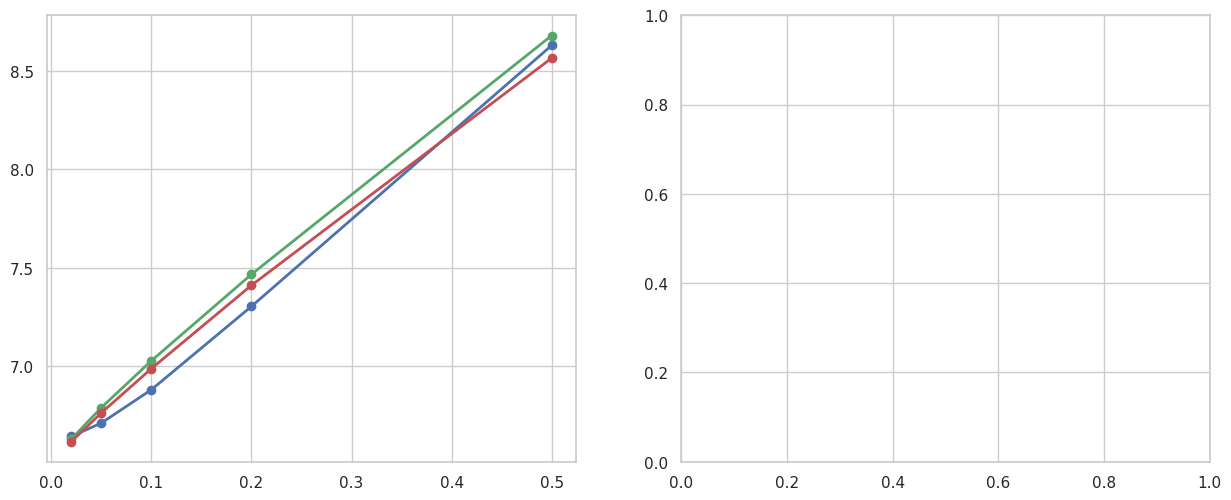

In [18]:
plot_metric(
    table=df_table,
    metric='mpjpe_px',
    ylabel='Dataset MPJPE (px)',
    x_col='network_period_s',
    xlabel='Network period (s)',
    output_name='mpjpe_vs_network_period_by_method.png',
)

plot_metric(
    table=df_table,
    metric='mpjpe_px',
    ylabel='Dataset MPJPE (px)',
    x_col='detection_rate_hz',
    xlabel='Detection rate (Hz)',
    output_name='mpjpe_vs_detection_rate_by_method.png',
)


## PCK@0.2 and PCK@0.4 comparison


In [ ]:
for th in PCK_THRESHOLDS:
    pck_col = f'pck_{th:.1f}'
    plot_metric(
        table=df_table,
        metric=pck_col,
        ylabel=f'Dataset PCK@{th:.1f} (%)',
        x_col='network_period_s',
        xlabel='Network period (s)',
        output_name=f'pck_{th:.1f}_vs_network_period_by_method.png',
        ylim=(10, 105),
    )

    plot_metric(
        table=df_table,
        metric=pck_col,
        ylabel=f'Dataset PCK@{th:.1f} (%)',
        x_col='detection_rate_hz',
        xlabel='Detection rate (Hz)',
        output_name=f'pck_{th:.1f}_vs_detection_rate_by_method.png',
        ylim=(40, 105),
    )


## Compact summary views


In [ ]:
summary_display = df_table[compact_cols].copy()
summary_display['mpjpe_px'] = summary_display['mpjpe_px'].round(3)
for col in pck_cols:
    summary_display[col] = summary_display[col].round(3)

display(summary_display)

best_mpjpe = (
    df_table
    .sort_values('mpjpe_px')
    .groupby(['dataset', 'network_period_s'], as_index=False)
    .head(1)
    [['dataset', 'network_period_s', 'detection_rate_hz', 'method_variant', 'mpjpe_px']]
    .sort_values(['dataset', 'network_period_s'])
)
print('Lowest MPJPE for each dataset/network period:')
display(best_mpjpe)

for col in pck_cols:
    best_pck = (
        df_table
        .sort_values(col, ascending=False)
        .groupby(['dataset', 'network_period_s'], as_index=False)
        .head(1)
        [['dataset', 'network_period_s', 'detection_rate_hz', 'method_variant', col]]
        .sort_values(['dataset', 'network_period_s'])
    )
    print(f'Highest {col.upper()} for each dataset/network period:')
    display(best_pck)
